# Visium HD Pancres — Train / Test Data Distribution

This notebook visualizes the spatial and expression distribution of train vs test cells,
confirming the tile-based spatial split is representative and not biased.

**Data:**
- 185,555 cells total
- 5×5 spatial grid split (4 test tiles, 3 val tiles, scattered)
- 1000 genes, already log1p-normalized

**Sections:**
1. Setup & load data
2. Spatial distribution (where are train/val/test cells on the tissue?)
3. Split counts and tile summary
4. Cell morphology distribution (area, diameter, aspect ratio)
5. Expression distribution (total counts, genes detected, sparsity)
6. Per-gene coverage in train vs test
7. Gene standardization stats (mean/std used for training)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.io as sio
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
CACHE     = Path('/hpc/group/jilab/tc459/MorphPT/cache_pancreas')
EXPR_ROOT = Path('/hpc/group/jilab/boxuan/visiumHD/human_pancreas')
MORPH_DIR = Path('/hpc/group/jilab/hz/MorphPT/data/visiumHD/human_pancreas')

STYLE = {
    'figure.dpi': 130,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
}
plt.rcParams.update(STYLE)

COLORS = {'train': '#4C72B0', 'val': '#55A868', 'test': '#C44E52', 'excluded': '#999999'}

print('Setup done.')

Setup done.


## 1. Load Data

In [2]:
# Load metadata (includes split assignments, morphology, spatial coords)
meta = pd.read_csv(CACHE / 'meta.csv')
print(f'Cells total : {len(meta):,}')
print(f'Columns     : {meta.columns.tolist()}')
meta.head(3)

Cells total : 185,555
Columns     : ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'x_bin', 'y_bin', 'tile_id', 'split']


,cell_id,x_centroid,y_centroid,mmap_idx,x_bin,y_bin,tile_id,split
0,Cell:10000,1141.247191,54438.333907,0,0,2,10,train
1,Cell:100000,6731.686582,47994.656665,1,1,1,6,val
2,Cell:100001,4630.575467,47531.629731,2,1,1,6,val


In [3]:
# Load expression matrix (already aligned to meta row order)
print('Loading expression matrix...')
expr = np.load(str(CACHE / 'expr.npy'), mmap_mode='r')   # (N, 1000)
genes = (EXPR_ROOT / 'expr/genes.txt').read_text().splitlines()
stats = np.load(str(CACHE / 'expr_stats.npz'))

print(f'Expression shape : {expr.shape}')
print(f'Genes            : {len(genes)}')
print(f'Gene mean range  : [{stats["gene_mean"].min():.3f}, {stats["gene_mean"].max():.3f}]')
print(f'Gene std range   : [{stats["gene_std"].min():.3f}, {stats["gene_std"].max():.3f}]')

Loading expression matrix...
Expression shape : (185555, 1000)
Genes            : 2250
Gene mean range  : [0.023, 1.593]
Gene std range   : [0.244, 2.220]


In [4]:
# Split counts
split_counts = meta['split'].value_counts()
print('Split counts:')
for s in ['train', 'val', 'test', 'excluded']:
    n = split_counts.get(s, 0)
    print(f'  {s:<10}: {n:>7,}  ({n/len(meta)*100:.1f}%)')

Split counts:
  train     : 133,829  (72.1%)
  val       :  20,267  (10.9%)
  test      :  31,459  (17.0%)
  excluded  :       0  (0.0%)


## 2. Spatial Distribution — Where Are Train/Val/Test Cells?

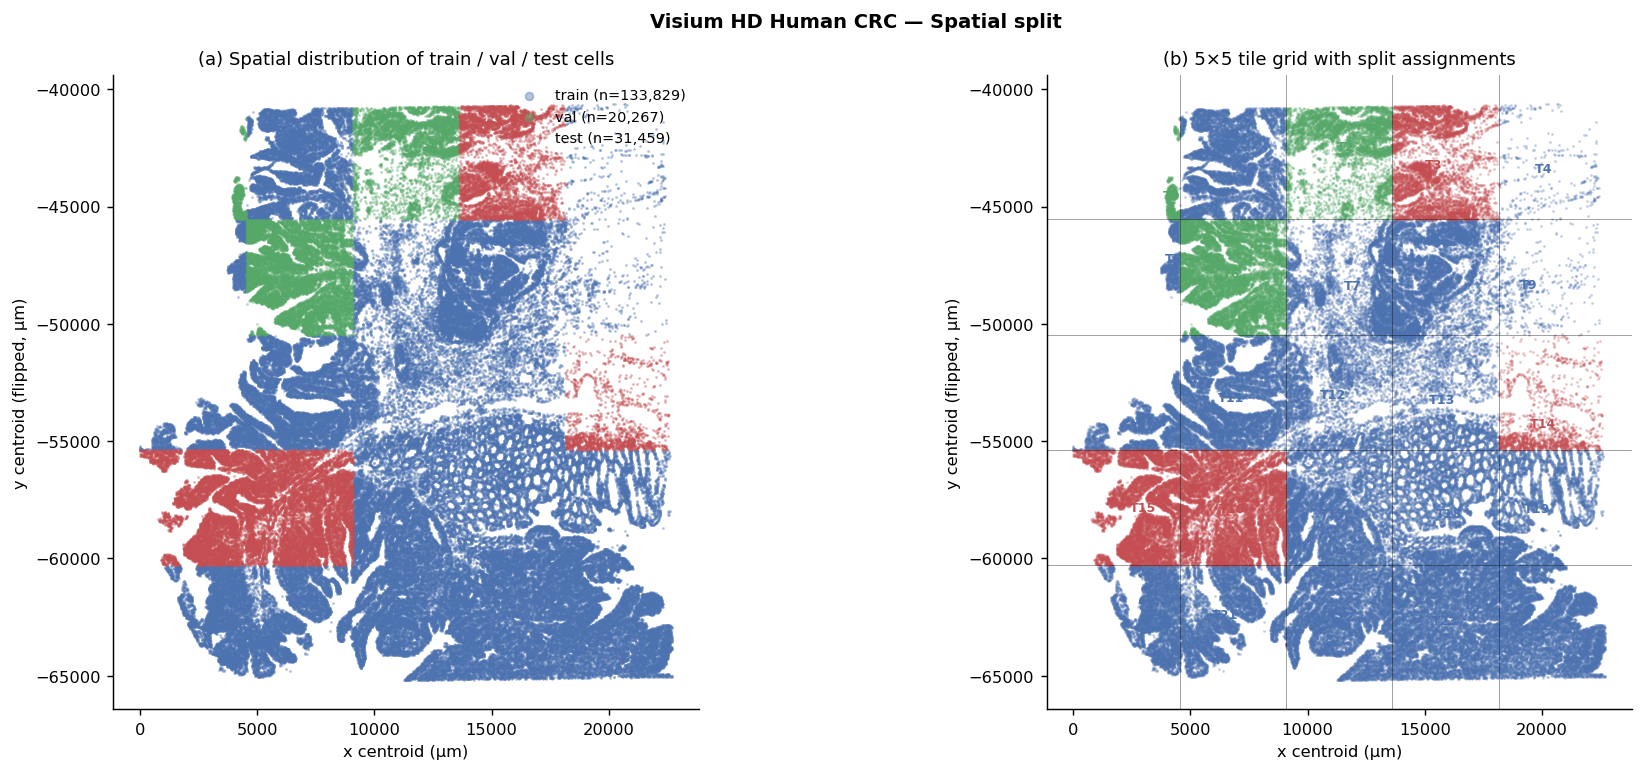

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: all cells colored by split
ax = axes[0]
for split in ['train', 'val', 'test', 'excluded']:
    mask = meta['split'] == split
    if mask.sum() == 0:
        continue
    ax.scatter(
        meta.loc[mask, 'x_centroid'],
        -meta.loc[mask, 'y_centroid'],   # flip y for anatomical orientation
        s=0.3, alpha=0.4,
        color=COLORS[split],
        label=f"{split} (n={mask.sum():,})",
        rasterized=True
    )
ax.set_xlabel('x centroid (µm)')
ax.set_ylabel('y centroid (flipped, µm)')
ax.set_title('(a) Spatial distribution of train / val / test cells', fontsize=10)
ax.legend(markerscale=8, fontsize=8)
ax.set_aspect('equal')

# Right: tile grid overlay
ax = axes[1]
for split in ['train', 'val', 'test']:
    mask = meta['split'] == split
    ax.scatter(
        meta.loc[mask, 'x_centroid'],
        -meta.loc[mask, 'y_centroid'],
        s=0.3, alpha=0.3,
        color=COLORS[split],
        rasterized=True
    )

# Draw tile grid
x_min, x_max = meta['x_centroid'].min(), meta['x_centroid'].max()
y_min, y_max = meta['y_centroid'].min(), meta['y_centroid'].max()
for i in range(1, 5):
    x_line = x_min + (x_max - x_min) * i / 5
    ax.axvline(x_line, color='black', lw=0.5, alpha=0.4)
for i in range(1, 5):
    y_line = -(y_min + (y_max - y_min) * i / 5)
    ax.axhline(y_line, color='black', lw=0.5, alpha=0.4)

# Annotate tile IDs
for tid in sorted(meta['tile_id'].unique()):
    tile_df = meta[meta['tile_id'] == tid]
    cx = tile_df['x_centroid'].mean()
    cy = -tile_df['y_centroid'].mean()
    split = tile_df['split'].iloc[0]
    ax.annotate(f'T{tid}', (cx, cy), ha='center', va='center',
                fontsize=7, color=COLORS.get(split, 'black'),
                fontweight='bold')

ax.set_xlabel('x centroid (µm)')
ax.set_ylabel('y centroid (flipped, µm)')
ax.set_title('(b) 5×5 tile grid with split assignments', fontsize=10)
ax.set_aspect('equal')

fig.suptitle('Visium HD Human CRC — Spatial split', fontweight='bold')
fig.tight_layout()
plt.show()

## 3. Split Counts and Tile Summary

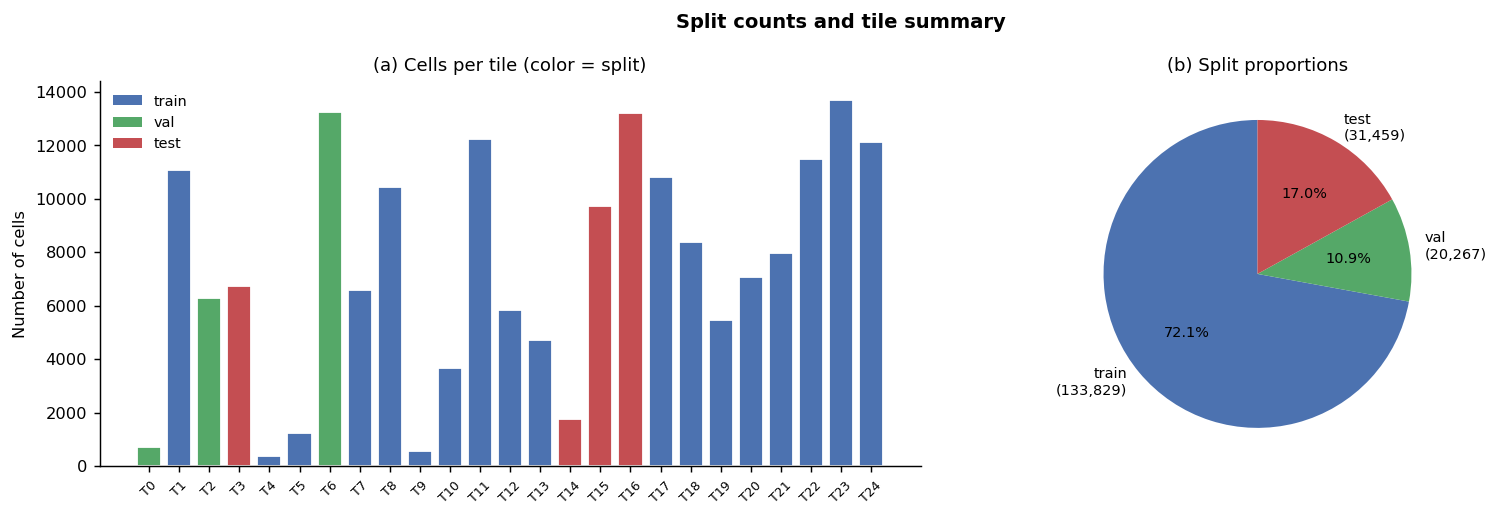

In [6]:
# Per-tile summary
tile_summary = meta.groupby(['tile_id', 'split']).size().reset_index(name='n_cells')
tile_summary = tile_summary.sort_values('tile_id')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart of cells per tile, colored by split
ax = axes[0]
tile_ids = sorted(meta['tile_id'].unique())
tile_counts = []
tile_splits = []
for tid in tile_ids:
    n = (meta['tile_id'] == tid).sum()
    s = meta.loc[meta['tile_id'] == tid, 'split'].iloc[0]
    tile_counts.append(n)
    tile_splits.append(s)

bar_colors = [COLORS.get(s, '#aaa') for s in tile_splits]
ax.bar(range(len(tile_ids)), tile_counts, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(tile_ids)))
ax.set_xticklabels([f'T{t}' for t in tile_ids], fontsize=7, rotation=45)
ax.set_ylabel('Number of cells')
ax.set_title('(a) Cells per tile (color = split)', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[s], label=s)
                   for s in ['train', 'val', 'test', 'excluded'] if s in tile_splits]
ax.legend(handles=legend_elements, fontsize=8)

# Right: pie chart of split proportions
ax = axes[1]
counts = [split_counts.get(s, 0) for s in ['train', 'val', 'test', 'excluded']]
labels = [f"{s}\n({n:,})" for s, n in zip(['train', 'val', 'test', 'excluded'], counts) if n > 0]
colors = [COLORS[s] for s, n in zip(['train', 'val', 'test', 'excluded'], counts) if n > 0]
sizes  = [n for n in counts if n > 0]
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title('(b) Split proportions', fontsize=10)

fig.suptitle('Split counts and tile summary', fontweight='bold')
fig.tight_layout()
plt.show()

## 4. Cell Morphology Distribution

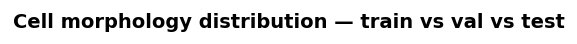


Morphology summary (mean ± std):


In [7]:
morph_cols = ['biological_area_um2', 'biological_diameter_um', 'aspect_ratio', 'coverage']
morph_labels = ['Nuclear area (µm²)', 'Nuclear diameter (µm)', 'Aspect ratio', 'Coverage']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for i, (col, label) in enumerate(zip(morph_cols, morph_labels)):
    if col not in meta.columns:
        axes[i].set_visible(False)
        continue
    ax = axes[i]
    for split in ['train', 'val', 'test']:
        vals = meta.loc[meta['split'] == split, col].dropna()
        ax.hist(vals, bins=60, alpha=0.5, color=COLORS[split],
                label=f"{split} (n={len(vals):,})",
                density=True, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'({chr(97+i)}) {label} distribution', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Cell morphology distribution — train vs val vs test', fontweight='bold')
fig.tight_layout()
plt.show()

# Summary stats
print('\nMorphology summary (mean ± std):')
for col, label in zip(morph_cols, morph_labels):
    if col not in meta.columns:
        continue
    print(f'\n  {label}:')
    for split in ['train', 'val', 'test']:
        vals = meta.loc[meta['split'] == split, col].dropna()
        print(f'    {split:<8}: {vals.mean():.3f} ± {vals.std():.3f}')

## 5. Expression Distribution

In [8]:
# Compute per-cell stats per split
print('Computing expression stats per split (may take ~30s)...')

split_expr = {}
for split in ['train', 'val', 'test']:
    idx = meta.loc[meta['split'] == split, 'mmap_idx'].values
    X   = np.array(expr[idx], dtype=np.float32)
    split_expr[split] = {
        'total_counts':   X.sum(axis=1),
        'genes_detected': (X > 0).sum(axis=1),
        'sparsity':       (X == 0).mean(axis=1),
        'X':              X,
    }
    print(f'  {split}: {len(idx):,} cells loaded')

print('Done.')

Computing expression stats per split (may take ~30s)...
  train: 133,829 cells loaded
  val: 20,267 cells loaded
  test: 31,459 cells loaded
Done.


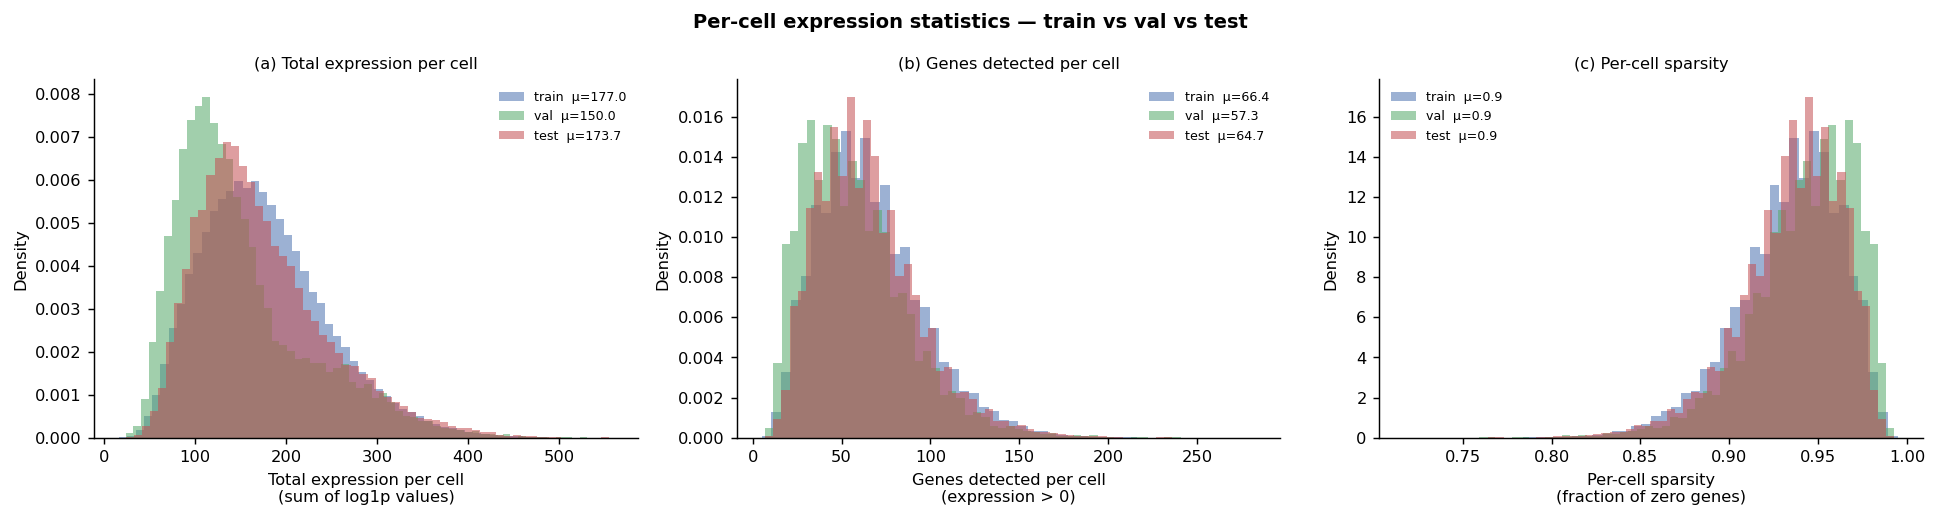

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('total_counts',   'Total expression per cell\n(sum of log1p values)', 60),
    ('genes_detected', 'Genes detected per cell\n(expression > 0)',         50),
    ('sparsity',       'Per-cell sparsity\n(fraction of zero genes)',        50),
]

for i, (key, label, bins) in enumerate(metrics):
    ax = axes[i]
    for split in ['train', 'val', 'test']:
        vals = split_expr[split][key]
        ax.hist(vals, bins=bins, alpha=0.55, color=COLORS[split],
                label=f"{split}  μ={vals.mean():.1f}",
                density=True, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'({chr(97+i)}) {label.split(chr(10))[0]}', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Per-cell expression statistics — train vs val vs test', fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Per-Gene Coverage — Train vs Test

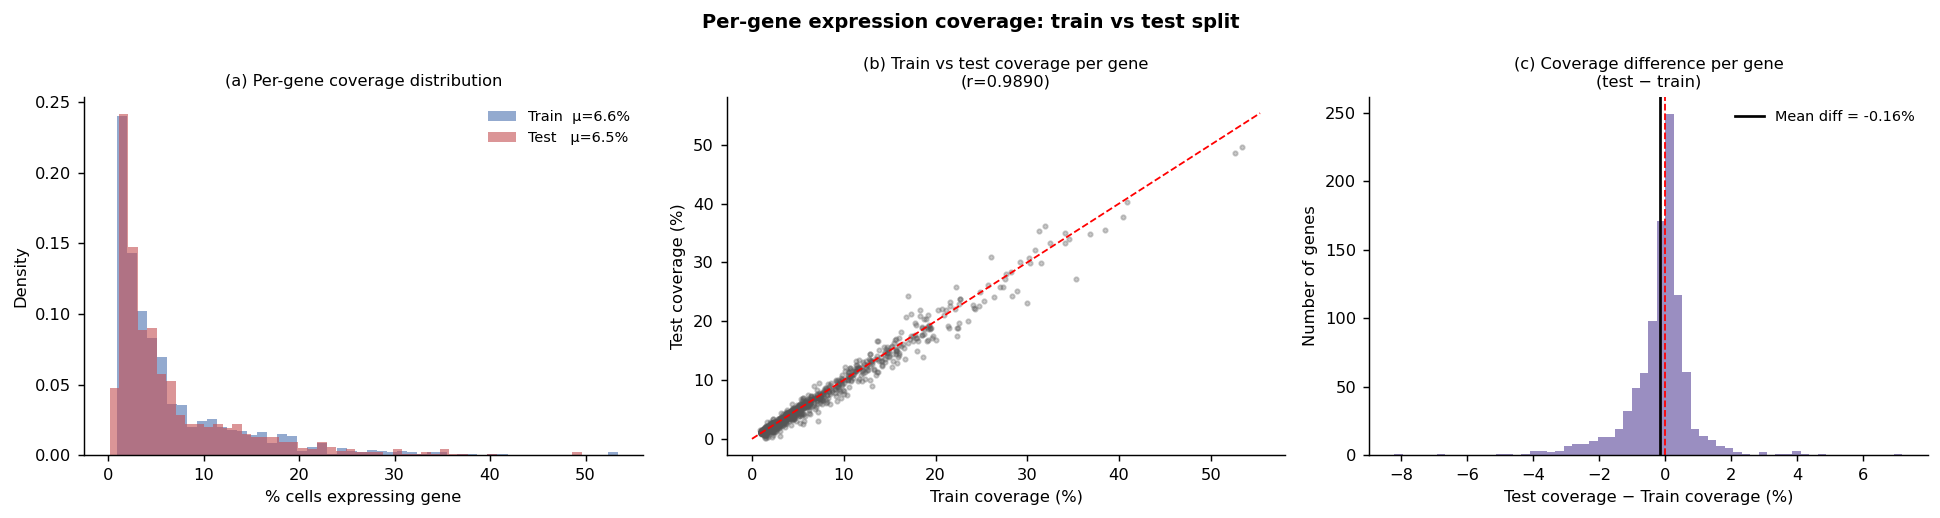

Coverage correlation (train vs test): r = 0.9890
Mean coverage difference: -0.163%  (std=1.044%)
Genes where test > train by >5%: 1
Genes where train > test by >5%: 2


In [10]:
# Per-gene fraction of expressing cells
coverage_train = (split_expr['train']['X'] > 0).mean(axis=0)  # (1000,)
coverage_test  = (split_expr['test']['X']  > 0).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: histogram of coverage values
ax = axes[0]
ax.hist(coverage_train * 100, bins=50, alpha=0.6, color=COLORS['train'],
        label=f'Train  μ={coverage_train.mean()*100:.1f}%', density=True, edgecolor='none')
ax.hist(coverage_test  * 100, bins=50, alpha=0.6, color=COLORS['test'],
        label=f'Test   μ={coverage_test.mean()*100:.1f}%',  density=True, edgecolor='none')
ax.set_xlabel('% cells expressing gene')
ax.set_ylabel('Density')
ax.set_title('(a) Per-gene coverage distribution', fontsize=9)
ax.legend(fontsize=8)

# Middle: scatter train vs test coverage per gene
ax = axes[1]
ax.scatter(coverage_train * 100, coverage_test * 100,
           alpha=0.3, s=6, color='#555555', rasterized=True)
lim = [0, max(coverage_train.max(), coverage_test.max()) * 100 + 2]
ax.plot(lim, lim, 'r--', lw=1)
r_cov = np.corrcoef(coverage_train, coverage_test)[0, 1]
ax.set_xlabel('Train coverage (%)')
ax.set_ylabel('Test coverage (%)')
ax.set_title(f'(b) Train vs test coverage per gene\n(r={r_cov:.4f})', fontsize=9)

# Right: coverage difference distribution
ax = axes[2]
diff = (coverage_test - coverage_train) * 100
ax.hist(diff, bins=60, color='#8172B2', alpha=0.8, edgecolor='none')
ax.axvline(0, color='red', lw=1, ls='--')
ax.axvline(diff.mean(), color='black', lw=1.5, ls='-',
           label=f'Mean diff = {diff.mean():.2f}%')
ax.set_xlabel('Test coverage − Train coverage (%)')
ax.set_ylabel('Number of genes')
ax.set_title('(c) Coverage difference per gene\n(test − train)', fontsize=9)
ax.legend(fontsize=8)

fig.suptitle('Per-gene expression coverage: train vs test split', fontweight='bold')
fig.tight_layout()
plt.show()

print(f'Coverage correlation (train vs test): r = {r_cov:.4f}')
print(f'Mean coverage difference: {diff.mean():.3f}%  (std={diff.std():.3f}%)')
print(f'Genes where test > train by >5%: {(diff > 5).sum()}')
print(f'Genes where train > test by >5%: {(diff < -5).sum()}')

## 7. Gene Standardization Stats

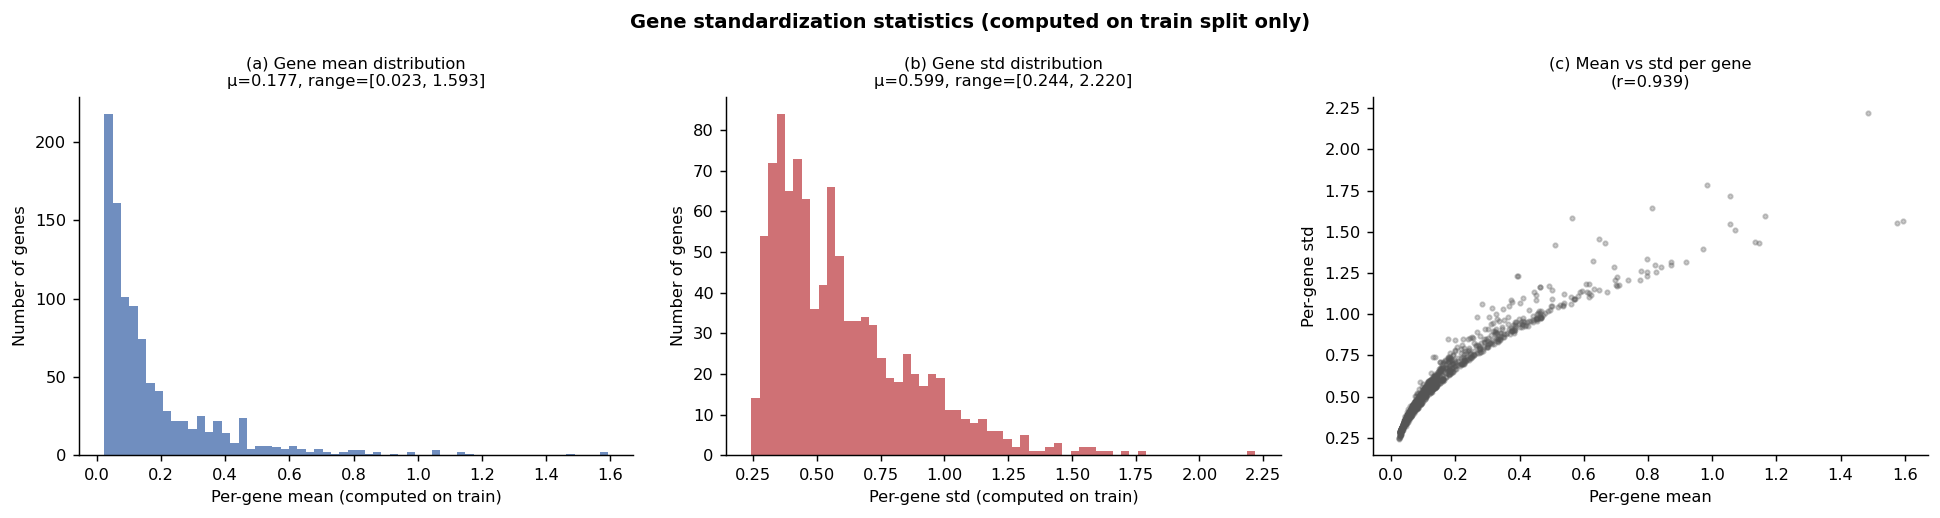

Top 15 genes by mean expression (on train cells):
    gene     mean      std       cv  coverage_train  coverage_test
   PHGR1 1.593293 1.566617 0.983257        0.533584       0.495884
  PRSS23 1.575023 1.554395 0.986903        0.526433       0.486633
    IGKC 1.484434 2.219592 1.495244        0.384976       0.355034
    LCN2 1.165751 1.598367 1.371106        0.368366       0.347754
HIST1H1C 1.147229 1.430759 1.247144        0.408133       0.403096
  TSPAN8 1.133050 1.440299 1.271169        0.403903       0.376935
   FABP1 1.069555 1.513002 1.414609        0.352958       0.270924
     VIM 1.056606 1.719502 1.627383        0.291596       0.300677
    CD74 1.053867 1.547403 1.468310        0.341391       0.333704
  COL3A1 0.984641 1.785748 1.813604        0.257538       0.261356
HIST1H1B 0.970950 1.395957 1.437724        0.341286       0.350710
  TXNDC5 0.917438 1.314777 1.433095        0.345785       0.339871
    SOD2 0.871674 1.299531 1.490846        0.325221       0.332147
    EGR1 0.8

In [11]:
gene_mean = stats['gene_mean']
gene_std  = stats['gene_std']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean
ax = axes[0]
ax.hist(gene_mean, bins=60, color='#4C72B0', alpha=0.8, edgecolor='none')
ax.set_xlabel('Per-gene mean (computed on train)')
ax.set_ylabel('Number of genes')
ax.set_title(f'(a) Gene mean distribution\n'
             f'μ={gene_mean.mean():.3f}, range=[{gene_mean.min():.3f}, {gene_mean.max():.3f}]',
             fontsize=9)

# Std
ax = axes[1]
ax.hist(gene_std, bins=60, color='#C44E52', alpha=0.8, edgecolor='none')
ax.set_xlabel('Per-gene std (computed on train)')
ax.set_ylabel('Number of genes')
ax.set_title(f'(b) Gene std distribution\n'
             f'μ={gene_std.mean():.3f}, range=[{gene_std.min():.3f}, {gene_std.max():.3f}]',
             fontsize=9)

# Mean vs std scatter
ax = axes[2]
ax.scatter(gene_mean, gene_std, alpha=0.3, s=6, color='#555555', rasterized=True)
ax.set_xlabel('Per-gene mean')
ax.set_ylabel('Per-gene std')
r_ms = np.corrcoef(gene_mean, gene_std)[0, 1]
ax.set_title(f'(c) Mean vs std per gene\n(r={r_ms:.3f})', fontsize=9)

fig.suptitle('Gene standardization statistics (computed on train split only)',
             fontweight='bold')
fig.tight_layout()
plt.show()

# Top genes by mean expression
df_genes = pd.DataFrame({
    'gene':      genes,
    'mean':      gene_mean,
    'std':       gene_std,
    'cv':        gene_std / np.clip(gene_mean, 1e-5, None),  # coefficient of variation
    'coverage_train': coverage_train,
    'coverage_test':  coverage_test,
})

print('Top 15 genes by mean expression (on train cells):')
print(df_genes.sort_values('mean', ascending=False).head(15)[
    ['gene','mean','std','cv','coverage_train','coverage_test']
].to_string(index=False))

## 8. Summary — Is the Split Representative?

In [12]:
print('=' * 60)
print('SPLIT REPRESENTATIVENESS SUMMARY')
print('=' * 60)

# Coverage correlation
print(f'\nPer-gene coverage (train vs test):')
print(f'  Pearson r = {r_cov:.4f}  (1.0 = identical coverage distribution)')
print(f'  Mean diff = {diff.mean():.3f}%  (near zero = unbiased)')

# Morphology KS test
from scipy.stats import ks_2samp
print(f'\nMorphology KS test (train vs test):')
for col, label in zip(morph_cols, morph_labels):
    if col not in meta.columns:
        continue
    train_vals = meta.loc[meta['split'] == 'train', col].dropna().values
    test_vals  = meta.loc[meta['split'] == 'test',  col].dropna().values
    stat, pval = ks_2samp(train_vals, test_vals)
    flag = '⚠ DIFFERENT' if pval < 0.01 else '✓ similar'
    print(f'  {label:<25}: KS={stat:.4f}  p={pval:.4f}  {flag}')

# Expression stats
print(f'\nPer-cell expression stats (mean):')
for split in ['train', 'val', 'test']:
    tc = split_expr[split]['total_counts'].mean()
    gd = split_expr[split]['genes_detected'].mean()
    sp = split_expr[split]['sparsity'].mean()
    print(f'  {split:<8}: total_counts={tc:.1f}  genes_detected={gd:.1f}  sparsity={sp:.3f}')

print(f'\nConclusion:')
if r_cov > 0.99 and abs(diff.mean()) < 1.0:
    print('  Gene coverage is highly consistent between train and test splits.')
    print('  The spatial tile-based split is representative of the full dataset.')
else:
    print('  ⚠ Some coverage differences detected — consider running multiple split seeds.')

SPLIT REPRESENTATIVENESS SUMMARY

Per-gene coverage (train vs test):
  Pearson r = 0.9890  (1.0 = identical coverage distribution)
  Mean diff = -0.163%  (near zero = unbiased)

Morphology KS test (train vs test):

Per-cell expression stats (mean):
  train   : total_counts=177.0  genes_detected=66.4  sparsity=0.934
  val     : total_counts=150.0  genes_detected=57.3  sparsity=0.943
  test    : total_counts=173.7  genes_detected=64.7  sparsity=0.935

Conclusion:
  ⚠ Some coverage differences detected — consider running multiple split seeds.
